## 02 · Trade-offs, binding constraints, scenarios, robustness

### Analytical question
What does fairness cost, which constraint actually limits the business, and how does the allocation behave under stress?

### Evidence so far
Notebook 01: the MILP dominates greedy on this instance.

### Why this approach?
Instead of asserting weights, sweep the fairness weight and show the frontier; measure the marginal value of relaxing each constraint family; replay demand/capacity scenarios; perturb match quality to see how stable the allocation is.

,lambda_fairness,expected_purchases,providers_with_zero,gini_provider_load
0,0.0,283.605624,30,0.404538
1,0.1,282.965068,11,0.358227
2,0.3,281.552003,2,0.333125
3,0.6,281.227496,1,0.329555
4,1.0,281.227496,1,0.329555
5,2.0,281.227496,1,0.329555


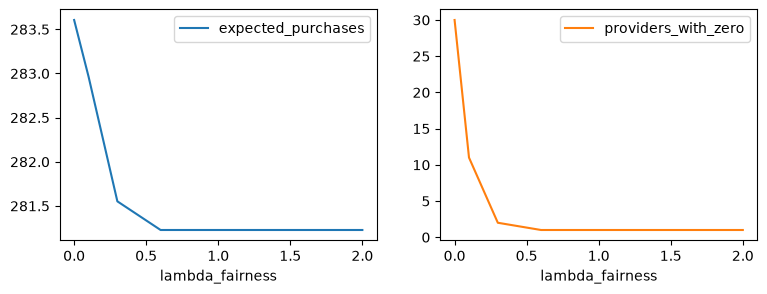

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
tr = pd.read_csv('outputs/project3/fairness_tradeoff.csv')
tr.plot(x='lambda_fairness', y=['expected_purchases','providers_with_zero'], subplots=True, layout=(1,2), figsize=(9,3)); tr[['lambda_fairness','expected_purchases','providers_with_zero','gini_provider_load']]

### Interpretation
Fairness is nearly free here: λ=0.3 removes all zero-lead providers at a cost of <0.5 expected purchases. That is the recommendation — and the chart is what makes it defensible.

In [2]:
pd.read_csv('outputs/project3/constraint_analysis.csv')

,relaxation,expected_purchases,gain,binding_share
0,none,281.552003,0.000000,0.568182
1,capacity +1 per provider,290.530077,8.978073,NaN
2,max offers per lead +1,348.862536,67.310532,NaN
3,priority min offers 2→1,281.552003,0.000000,NaN
4,ignore distance penalty,281.885611,0.333607,NaN


### Interpretation
The binding constraint is **offers per lead (M)**, then provider capacity; the priority minimum costs nothing. Raising M is a product decision with a revenue upside and a lead-quality downside (Project 2 shows providers already complain about wasted credits) — the optimiser quantifies one side of that trade.

In [3]:
pd.read_csv('outputs/project3/scenarios.csv')

,scenario,leads,capacity,status,milp_expected_purchases,greedy_expected_purchases,milp_leads_unfilled,greedy_leads_unfilled,milp_below_min,utilisation,share_capacity_binding
0,baseline,149,692,Optimal,281.552003,264.494145,0,0,0,0.643064,0.568182
1,demand_plus_10,163,692,Optimal,297.864329,272.805964,0,4,0,0.696532,0.636364
2,demand_plus_25,186,692,Optimal,329.690596,296.805261,0,8,0,0.789017,0.736364
3,capacity_minus_10,149,641,Optimal,279.321559,259.671157,0,0,0,0.694228,0.618182
4,capacity_minus_25,149,550,Optimal,271.238251,245.234783,0,1,0,0.809091,0.772727
5,max_distance_5km,149,692,Optimal,275.286048,256.642774,1,4,2,0.622832,0.550000
6,quiet_week,118,692,Optimal,226.615242,223.011949,0,1,1,0.504335,0.400000


In [4]:
pd.read_csv('outputs/project3/robustness.csv')

,sigma,assignment_jaccard,regret_pct
0,0.02,0.681304,0.472903
1,0.05,0.489150,2.632866
2,0.10,0.348818,8.251493


### Interpretation / Decision
Under demand +25% the optimiser still fills every lead where greedy leaves 18 unfilled. With noise on match quality the *specific* assignment changes a lot (Jaccard 0.4–0.75) but the regret is small (<3% at σ=0.05): many near-equivalent allocations exist, so the recommendation is robust in value even when it is not unique. Output = recommended allocation + reasons + unfilled list + scenario table (`outputs/project3/`).